In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg16

from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn

In [2]:
print(f"Using the PyTorch version: {torch.__version__}")

## getting the device
device = "cuda" if torch.cuda.is_available() else 'cpu'
print(f"Device:{device}")

Using the PyTorch version: 2.8.0+cu128
Device:cuda


In [3]:
## setting seed for reproducibility
torch.manual_seed(42)

In [4]:
## Reading the data
df = pd.read_csv('/home/prashant/Documents/ML-DL/PyTorch/fashion-mnist_train.csv')
print('-'*5,'First 10 rows','-'*5,'\n')
display(df.head(10))
print(f'Shape of the FashionMNIST Dataset:{df.shape}')

----- First 10 rows ----- 



,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,4,0,0,0,5,4,5,5,3,5,...,7,8,7,4,3,7,5,0,0,0
6,4,0,0,0,0,0,0,0,0,0,...,14,0,0,0,0,0,0,0,0,0
7,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,4,0,0,0,0,0,0,3,2,0,...,1,0,0,0,0,0,0,0,0,0
9,8,0,0,0,0,0,0,0,0,0,...,203,214,166,0,0,0,0,0,0,0


Shape of the FashionMNIST Dataset:(60000, 785)


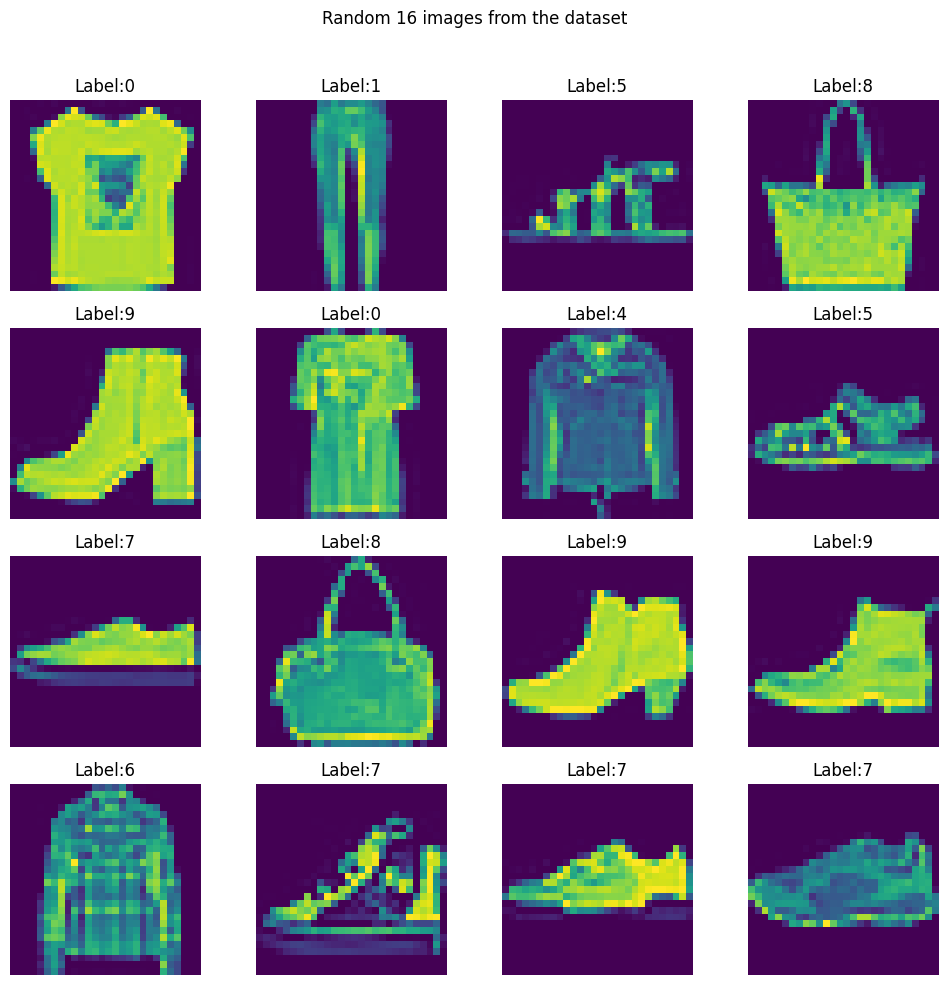

In [5]:
## Displaying few random datasets
fig, ax = plt.subplots(4,4,figsize=(10,10))
fig.suptitle('Random 16 images from the dataset', fontsize=12)

data = df.sample(16)

for i, axes in enumerate(ax.flatten()):
    image = data.iloc[i,1:].values.reshape(28,28)
    axes.imshow(image)
    axes.set_title(f"Label:{data.iloc[i,0]}")
    axes.axis('off')

plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [6]:
## Train test split
X = df.drop('label', axis=1).values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

print(f"Shape of the splited data:\nX_train:{X_train.shape}\ny_train:{y_train.shape}\nX_test:{X_test.shape}\ny_test:{y_test.shape}")

Shape of the splited data:
X_train:(48000, 784)
y_train:(48000,)
X_test:(12000, 784)
y_test:(12000,)


In [8]:
from torchvision import transforms

custom_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [9]:
from PIL import Image

class CustomImageDataset(Dataset):
    def __init__(self, X, y, transform):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        # Reshaping the image from (784,) to (28,28) and converting to uint8 for PIL compatibility
        image = self.X[idx].reshape(28,28).astype(np.uint8)

        # change B&W to RGB by stacking the same image 3 times -> (H,W,C) -> (C,H,W)
        image = np.stack([image]*3, axis=-1)

        # convert to PIL image
        image = Image.fromarray(image)

        # Apply the transformations
        if self.transform:
            image = self.transform(image)

        label = torch.tensor(self.y[idx],dtype=torch.long)

        return image, label

In [18]:
train_set = CustomImageDataset(X_train, y_train, transform=custom_transform)
test_set = CustomImageDataset(X_test, y_test, transform=custom_transform)

In [19]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False, pin_memory=True)

In [11]:
# Fetch the pretrained VGG16 model
vgg16_model = vgg16(pretrained=True)

vgg16_model

/home/prashant/.conda/envs/deeplearning/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/prashant/.conda/envs/deeplearning/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /home/prashant/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:19<00:00, 27.7MB/s] 


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [12]:
for params in vgg16_model.features.parameters():
    params.requires_grad = False

In [13]:
vgg16_model.classifier = nn.Sequential(
    nn.Linear(in_features=25088, out_features=1024),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=1024, out_features=512),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(in_features=512, out_features=10)
)

In [14]:
vgg16_model

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [15]:
vgg16_model = vgg16_model.to(device)

In [16]:
# Model Params
epochs = 10
learning_rate = 0.0001

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16_model.classifier.parameters(), lr=learning_rate)

In [20]:
## Training loop

for epoch in range(epochs):

    total_epoch_loss = 0

    for batch_X, batch_y in train_loader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        # Forward pass
        y_pred = vgg16_model(batch_X)
        loss = criterion(y_pred, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # update grads
        optimizer.step()

        total_epoch_loss += loss.item()

    avg_epoch_loss = total_epoch_loss / len(train_loader)
    print(f"Epoch:{epoch+1}/{epochs:<3}, Loss:{avg_epoch_loss:.4f}")

Epoch:1/10 , Loss:0.3665
Epoch:2/10 , Loss:0.2191
Epoch:3/10 , Loss:0.1640
Epoch:4/10 , Loss:0.1309
Epoch:5/10 , Loss:0.1045
Epoch:6/10 , Loss:0.0809
Epoch:7/10 , Loss:0.0679
Epoch:8/10 , Loss:0.0538
Epoch:9/10 , Loss:0.0472
Epoch:10/10 , Loss:0.0397


In [21]:
vgg16_model.eval()

# Evaluation loop on test data

total_correct = 0
total_samples = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        y_pred = vgg16_model(batch_X)
        _, predicted_labels = torch.max(y_pred, 1)

        total_samples = total_samples + batch_y.shape[0]

        total_correct += (predicted_labels == batch_y).sum().item()

accuracy = total_correct / total_samples * 100
print(f"Test Accuracy:{accuracy:.4f}")

Test Accuracy:92.8833


In [23]:
vgg16_model.eval()

# Evaluation loop on test data

total_correct = 0
total_samples = 0

with torch.no_grad():
    for batch_X, batch_y in train_loader:

        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        y_pred = vgg16_model(batch_X)
        _, predicted_labels = torch.max(y_pred, 1)

        total_samples = total_samples + batch_y.shape[0]

        total_correct += (predicted_labels == batch_y).sum().item()

accuracy = total_correct / total_samples * 100
print(f"Train Accuracy:{accuracy:.4f}")

Train Accuracy:99.7625
